# Jason Brownlee's "Your First Machine Learning Project in R Step-By-Step"
Author: Josephine Stark 
Email: j.stark.grad@gmail.com
Credits: Jason Brownlee for tutorial and CSV file data

In [1]:
##ensure libraries are loaded for current session:
library(caret)
library(ellipse)

Loading required package: ggplot2

Loading required package: lattice


Attaching package: ‘ellipse’


The following object is masked from ‘package:graphics’:

    pairs




## Load Dataset
use R built-in iris dataset

In [2]:
data(iris)
dataset <- iris

## Create validation dataset

In [3]:
validation_index <- createDataPartition(dataset$Species, p=0.80, list=FALSE)
validation <- dataset[-validation_index,]
dataset <- dataset[validation_index,]

## summarize dataset
this section includes the following: 
1. Dimensions of the dataset.
2. Types of the attributes.
3. Peek at the data itself.
4. Levels of the class attribute.
5. Breakdown of the instances in each class.
6. Statistical summary of all attributes.

In [4]:
dim(dataset)
sapply(dataset,class)
head(dataset)
levels(dataset$Species)
percentage <- prop.table(table(dataset$Species)) * 100
cbind(freq=table(dataset$Species), percentage=percentage)
summary(dataset)

[1] 120   5

Sepal.Length  Sepal.Width Petal.Length  Petal.Width      Species 
   "numeric"    "numeric"    "numeric"    "numeric"     "factor"

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa


[1] "setosa"     "versicolor" "virginica"

,freq,percentage
setosa,40,33.33333
versicolor,40,33.33333
virginica,40,33.33333


  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.300   Min.   :2.200   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.300  
 Median :5.800   Median :3.000   Median :4.400   Median :1.300  
 Mean   :5.855   Mean   :3.076   Mean   :3.756   Mean   :1.207  
 3rd Qu.:6.400   3rd Qu.:3.325   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.700   Max.   :4.400   Max.   :6.700   Max.   :2.500  
       Species  
 setosa    :40  
 versicolor:40  
 virginica :40  
                
                
                

## Visualize dataset
### Univariate plots
Box plots:

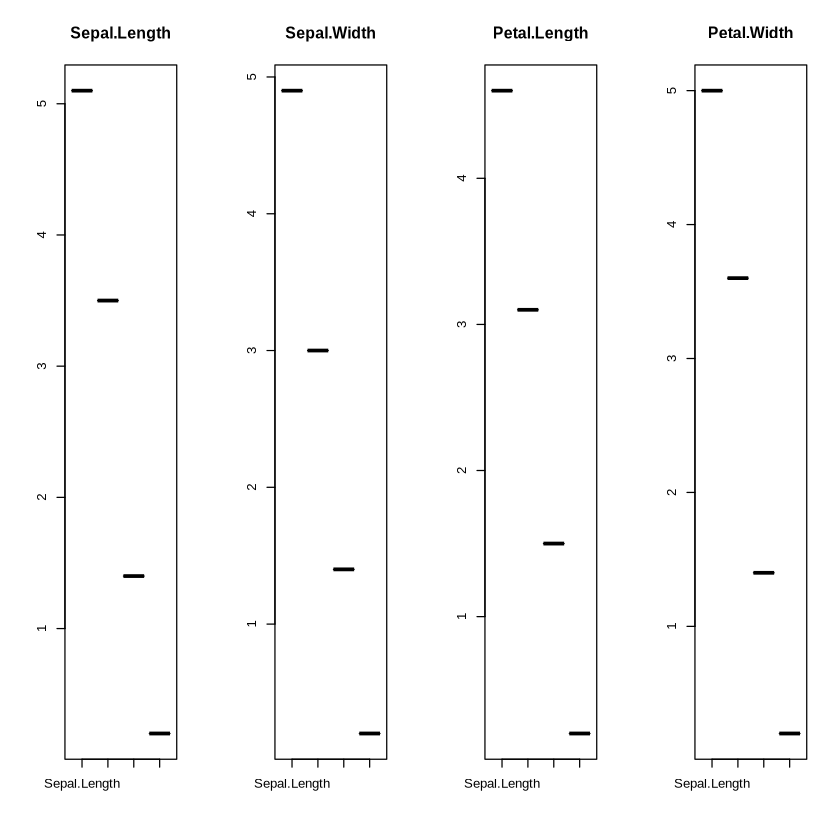

In [5]:
x <- dataset[,1:4]
y <- dataset[,5]
par(mfrow=c(1,4))
    for(i in 1:4){
        boxplot(x[i,], main=names(iris)[i])
}

Bar plot: 

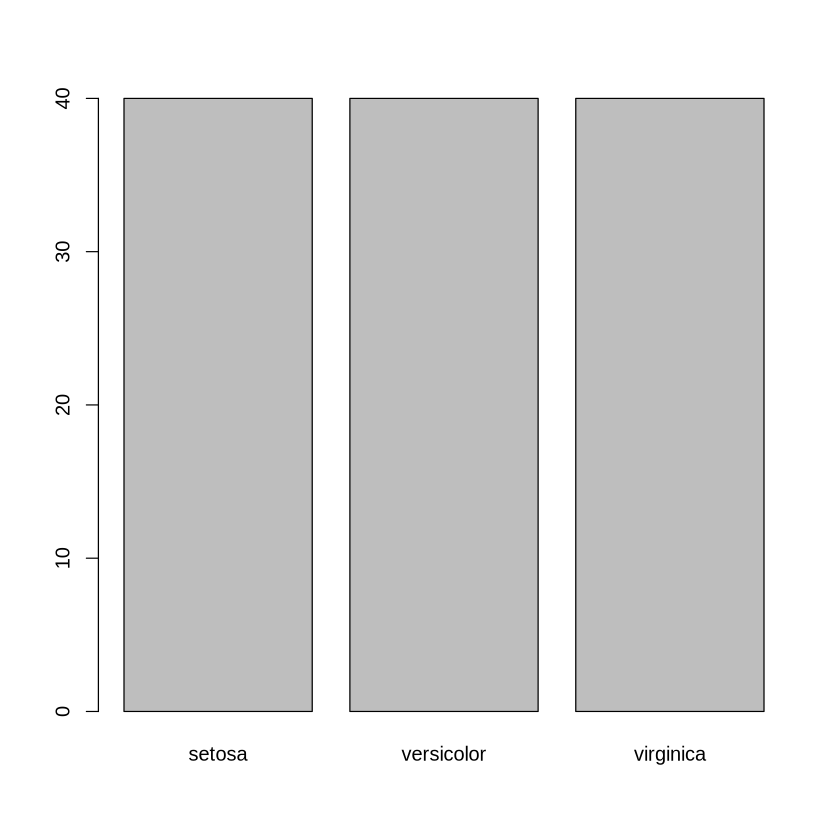

In [6]:
plot(y)

### Multivariate Plots
scatterplot matrix:

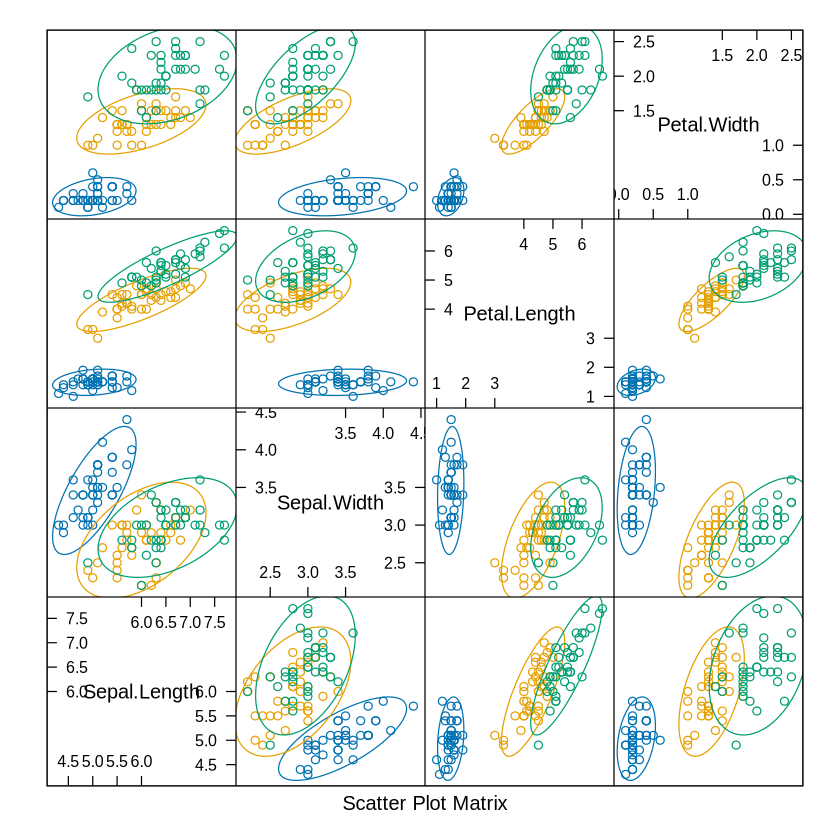

In [7]:
featurePlot(x=x, y=y, plot="ellipse")

box and wisker plots

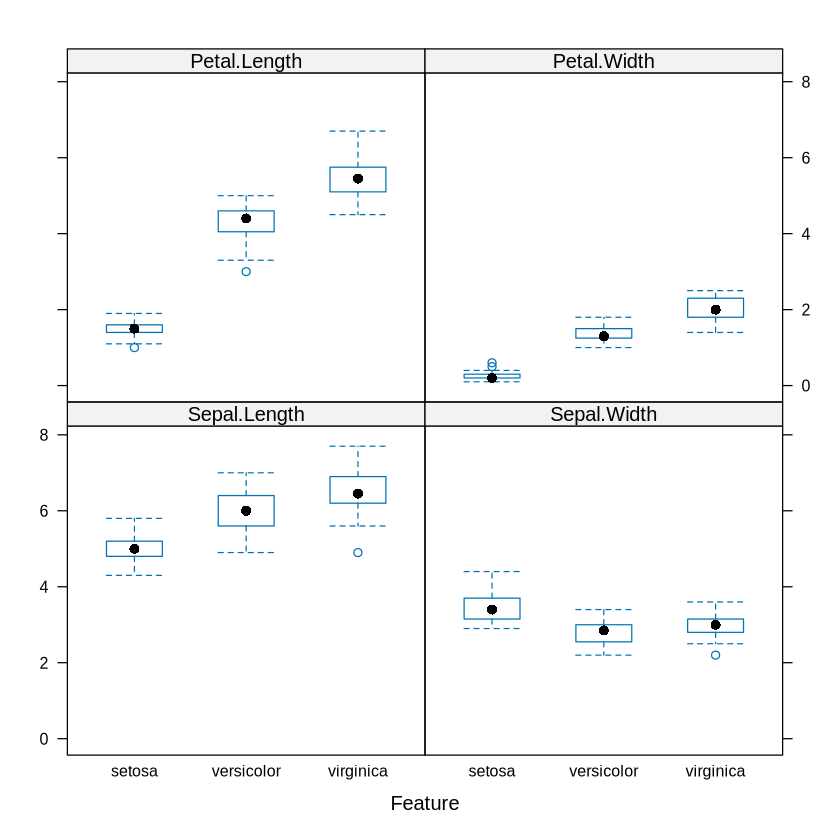

In [8]:
featurePlot(x=x, y=y, plot="box")

density plots

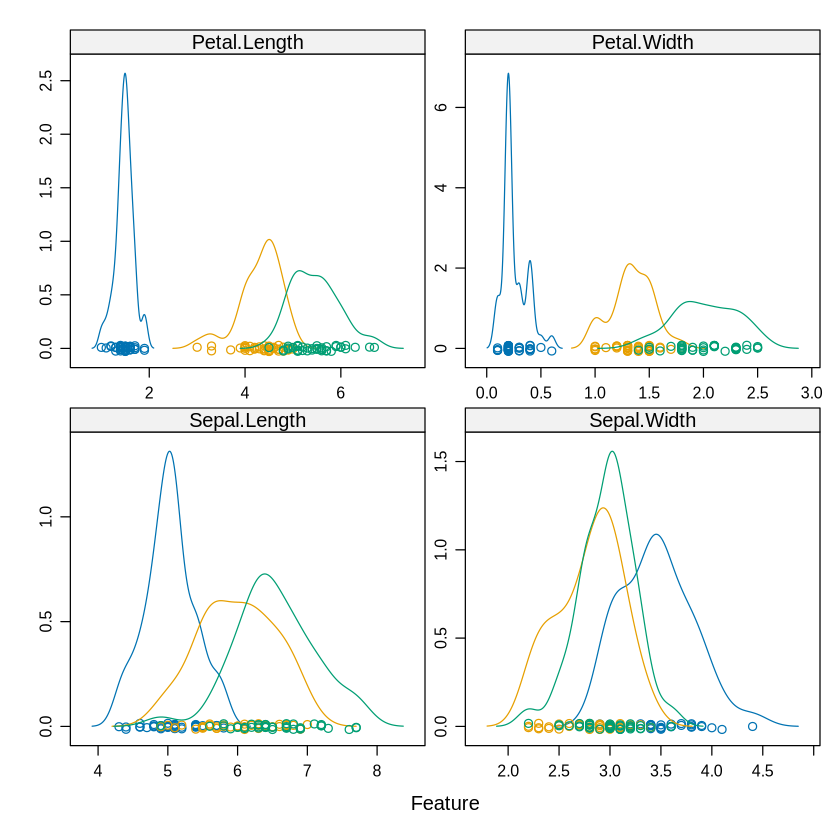

In [9]:
scales <- list(x=list(relation="free"), y=list(relation="free"))
featurePlot(x=x, y=y, plot="density", scales=scales)

## Evaluate Algoritms

In [10]:
# test hardness
control <- trainControl(method="cv", number=10)
metric <- "Accuracy"

Build 5 different algorithims then test on the model:
1. Linear Discriminant Analysis (LDA)
2. Classification and Regression Trees(CART).
3. k-Nearest Neighbors (kNN).
4. Support Vector Machines (SVM) with a linear kernel.
5. Random Forest (RF)

In [12]:
set.seed(7)
fit.lda <- train(Species~., data=dataset, method="lda", metric=metric, trControl=control)
set.seed(7)
fit.cart <- train(Species~., data=dataset, method="rpart", metric=metric, trControl=control)
set.seed(7)
fit.knn <- train(Species~., data=dataset, method="knn", metric=metric, trControl=control)
set.seed(7)
fit.svm <- train(Species~., data=dataset, method="svmRadial", metric=metric, trControl=control)
set.seed(7)
fit.rf <- train(Species~., data=dataset, method="rf", metric=metric, trControl=control)

In [13]:
results <- resamples(list(lda=fit.lda, cart=fit.cart, knn=fit.knn, svm=fit.svm, rf=fit.rf))
summary(results)


Call:
summary.resamples(object = results)

Models: lda, cart, knn, svm, rf 
Number of resamples: 10 

Accuracy 
          Min.   1st Qu.    Median      Mean   3rd Qu. Max. NA's
lda  0.8333333 1.0000000 1.0000000 0.9833333 1.0000000    1    0
cart 0.8333333 0.8541667 0.9166667 0.9083333 0.9166667    1    0
knn  0.9166667 0.9375000 1.0000000 0.9750000 1.0000000    1    0
svm  0.9166667 0.9166667 1.0000000 0.9666667 1.0000000    1    0
rf   0.9166667 0.9166667 1.0000000 0.9666667 1.0000000    1    0

Kappa 
      Min. 1st Qu. Median   Mean 3rd Qu. Max. NA's
lda  0.750 1.00000  1.000 0.9750   1.000    1    0
cart 0.750 0.78125  0.875 0.8625   0.875    1    0
knn  0.875 0.90625  1.000 0.9625   1.000    1    0
svm  0.875 0.87500  1.000 0.9500   1.000    1    0
rf   0.875 0.87500  1.000 0.9500   1.000    1    0


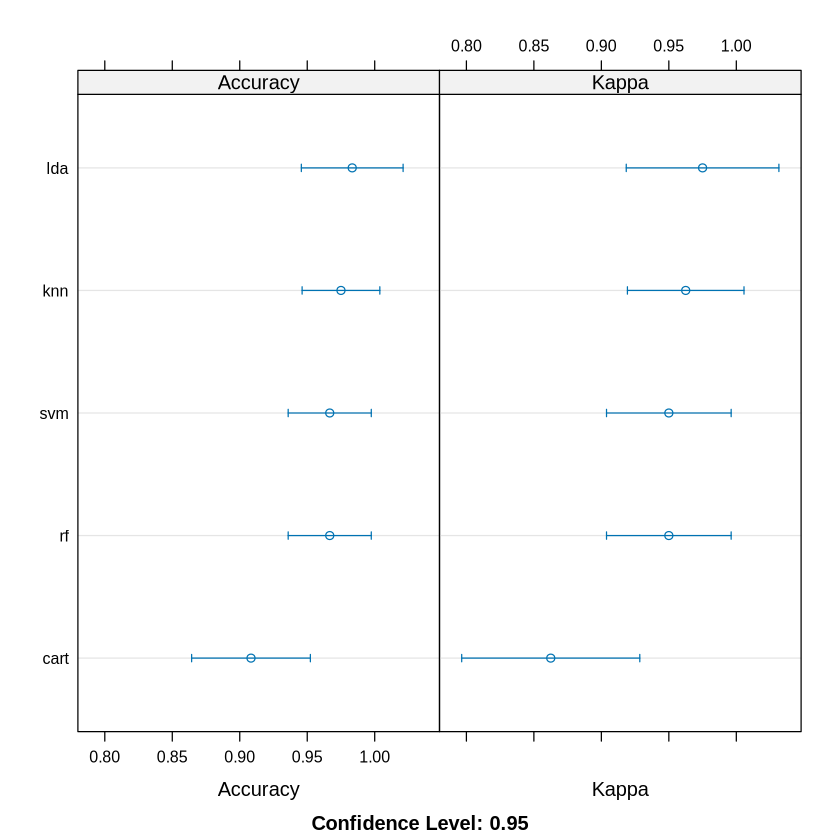

In [14]:
dotplot(results)

In [15]:
print(fit.lda)

Linear Discriminant Analysis 

120 samples
  4 predictor
  3 classes: 'setosa', 'versicolor', 'virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 108, 108, 108, 108, 108, 108, ... 
Resampling results:

  Accuracy   Kappa
  0.9833333  0.975



## Make predictions 
use LDA model, which test showed was the most accurate

In [16]:
predictions <- predict(fit.lda, validation)
confusionMatrix(predictions, validation$Species)

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         10          0         0
  versicolor      0          9         0
  virginica       0          1        10

Overall Statistics
                                          
               Accuracy : 0.9667          
                 95% CI : (0.8278, 0.9992)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : 2.963e-13       
                                          
                  Kappa : 0.95            
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            0.9000           1.0000
Specificity                 1.0000            1.0000           0.9500
Pos Pred Value              1.0000            1.0000           0.9091
Neg Pred Value              1.0000            0.9524           1.0000
P